# Исследование объявлений о продаже квартир

В вашем распоряжении данные сервиса Яндекс Недвижимость — архив объявлений о продаже квартир в Санкт-Петербурге и соседних населённых пунктах за несколько лет. Вам нужно научиться определять рыночную стоимость объектов недвижимости. Для этого проведите исследовательский анализ данных и установите параметры, влияющие на цену объектов. Это позволит построить автоматизированную систему: она отследит аномалии и мошенническую деятельность.

По каждой квартире на продажу доступны два вида данных. Первые вписаны пользователем, вторые — получены автоматически на основе картографических данных. Например, расстояние до центра, аэропорта и других объектов — эти данные автоматически получены из геосервисов. Количество парков и водоёмов также заполняется без участия пользователя.

### Откройте файл с данными и изучите общую информацию

In [1]:
# импорт библиотек
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
# прочтем данные и посмотрим первые 10 строк
df = pd.read_csv('/datasets/real_estate_data.csv', sep='\t')
pd.set_option('display.max_columns', None)
df.head(10)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
0,20,13000000.0,108.00,2019-03-07T00:00:00,3,2.70,16.0,51.00,8,NaN,False,False,25.00,NaN,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN
1,7,3350000.0,40.40,2018-12-04T00:00:00,1,NaN,11.0,18.60,1,NaN,False,False,11.00,2.0,посёлок Шушары,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0
2,10,5196000.0,56.00,2015-08-20T00:00:00,2,NaN,5.0,34.30,4,NaN,False,False,8.30,0.0,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0
3,0,64900000.0,159.00,2015-07-24T00:00:00,3,NaN,14.0,NaN,9,NaN,False,False,NaN,0.0,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0
4,2,10000000.0,100.00,2018-06-19T00:00:00,2,3.03,14.0,32.00,13,NaN,False,False,41.00,NaN,Санкт-Петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0
5,10,2890000.0,30.40,2018-09-10T00:00:00,1,NaN,12.0,14.40,5,NaN,False,False,9.10,NaN,городской посёлок Янино-1,NaN,NaN,NaN,NaN,NaN,NaN,55.0
6,6,3700000.0,37.30,2017-11-02T00:00:00,1,NaN,26.0,10.60,6,NaN,False,False,14.40,1.0,посёлок Парголово,52996.0,19143.0,0.0,NaN,0.0,NaN,155.0
7,5,7915000.0,71.60,2019-04-18T00:00:00,2,NaN,24.0,NaN,22,NaN,False,False,18.90,2.0,Санкт-Петербург,23982.0,11634.0,0.0,NaN,0.0,NaN,NaN
8,20,2900000.0,33.16,2018-05-23T00:00:00,1,NaN,27.0,15.43,26,NaN,False,False,8.81,NaN,посёлок Мурино,NaN,NaN,NaN,NaN,NaN,NaN,189.0
9,18,5400000.0,61.00,2017-02-26T00:00:00,3,2.50,9.0,43.60,7,NaN,False,False,6.50,2.0,Санкт-Петербург,50898.0,15008.0,0.0,NaN,0.0,NaN,289.0


In [3]:
# посмотрим последние 10 строк
df.tail(10)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
23689,13,3550000.0,35.30,2018-02-28T00:00:00,1,2.86,15.0,16.3,4,NaN,False,False,9.10,2.0,Санкт-Петербург,17284.0,16081.0,1.0,353.0,2.0,652.0,29.0
23690,3,5500000.0,52.00,2018-07-19T00:00:00,2,NaN,5.0,31.0,2,NaN,False,False,6.00,NaN,Санкт-Петербург,20151.0,6263.0,1.0,300.0,0.0,NaN,15.0
23691,11,9470000.0,72.90,2016-10-13T00:00:00,2,2.75,25.0,40.3,7,NaN,False,False,10.60,1.0,Санкт-Петербург,19424.0,4489.0,0.0,NaN,1.0,806.0,519.0
23692,2,1350000.0,30.00,2017-07-07T00:00:00,1,NaN,5.0,17.5,4,NaN,False,False,6.00,NaN,Тихвин,NaN,NaN,NaN,NaN,NaN,NaN,413.0
23693,9,4600000.0,62.40,2016-08-05T00:00:00,3,2.60,9.0,40.0,8,NaN,False,False,8.00,0.0,Петергоф,45602.0,34104.0,1.0,352.0,1.0,675.0,239.0
23694,9,9700000.0,133.81,2017-03-21T00:00:00,3,3.70,5.0,73.3,3,NaN,False,False,13.83,NaN,Санкт-Петербург,24665.0,4232.0,1.0,796.0,3.0,381.0,NaN
23695,14,3100000.0,59.00,2018-01-15T00:00:00,3,NaN,5.0,38.0,4,NaN,False,False,8.50,NaN,Тосно,NaN,NaN,NaN,NaN,NaN,NaN,45.0
23696,18,2500000.0,56.70,2018-02-11T00:00:00,2,NaN,3.0,29.7,1,NaN,False,False,NaN,NaN,село Рождествено,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23697,13,11475000.0,76.75,2017-03-28T00:00:00,2,3.00,17.0,NaN,12,NaN,False,False,23.30,2.0,Санкт-Петербург,39140.0,10364.0,2.0,173.0,3.0,196.0,602.0
23698,4,1350000.0,32.30,2017-07-21T00:00:00,1,2.50,5.0,12.3,1,NaN,False,False,9.00,NaN,поселок Новый Учхоз,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# посмотрим числовые данные
df.describe()

,total_images,last_price,total_area,rooms,ceiling_height,floors_total,living_area,floor,kitchen_area,balcony,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
count,23699.000000,2.369900e+04,23699.000000,23699.000000,14504.000000,23613.000000,21796.000000,23699.000000,21421.000000,12180.000000,18157.000000,18180.000000,18181.000000,8079.000000,18181.000000,9110.000000,20518.000000
mean,9.858475,6.541549e+06,60.348651,2.070636,2.771499,10.673824,34.457852,5.892358,10.569807,1.150082,28793.672193,14191.277833,0.611408,490.804555,0.770255,517.980900,180.888634
std,5.682529,1.088701e+07,35.654083,1.078405,1.261056,6.597173,22.030445,4.885249,5.905438,1.071300,12630.880622,8608.386210,0.802074,342.317995,0.938346,277.720643,219.727988
min,0.000000,1.219000e+04,12.000000,0.000000,1.000000,1.000000,2.000000,1.000000,1.300000,0.000000,0.000000,181.000000,0.000000,1.000000,0.000000,13.000000,1.000000
25%,6.000000,3.400000e+06,40.000000,1.000000,2.520000,5.000000,18.600000,2.000000,7.000000,0.000000,18585.000000,9238.000000,0.000000,288.000000,0.000000,294.000000,45.000000
50%,9.000000,4.650000e+06,52.000000,2.000000,2.650000,9.000000,30.000000,4.000000,9.100000,1.000000,26726.000000,13098.500000,0.000000,455.000000,1.000000,502.000000,95.000000
75%,14.000000,6.800000e+06,69.900000,3.000000,2.800000,16.000000,42.300000,8.000000,12.000000,2.000000,37273.000000,16293.000000,1.000000,612.000000,1.000000,729.000000,232.000000
max,50.000000,7.630000e+08,900.000000,19.000000,100.000000,60.000000,409.700000,33.000000,112.000000,5.000000,84869.000000,65968.000000,3.000000,3190.000000,3.000000,1344.000000,1580.000000


In [5]:
# посмотрим информацию 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   total_images          23699 non-null  int64  
 1   last_price            23699 non-null  float64
 2   total_area            23699 non-null  float64
 3   first_day_exposition  23699 non-null  object 
 4   rooms                 23699 non-null  int64  
 5   ceiling_height        14504 non-null  float64
 6   floors_total          23613 non-null  float64
 7   living_area           21796 non-null  float64
 8   floor                 23699 non-null  int64  
 9   is_apartment          2775 non-null   object 
 10  studio                23699 non-null  bool   
 11  open_plan             23699 non-null  bool   
 12  kitchen_area          21421 non-null  float64
 13  balcony               12180 non-null  float64
 14  locality_name         23650 non-null  object 
 15  airports_nearest   

In [6]:
# проверим надупликаты
df.duplicated().sum()
# хоть ответ нет, но они могут быть

0

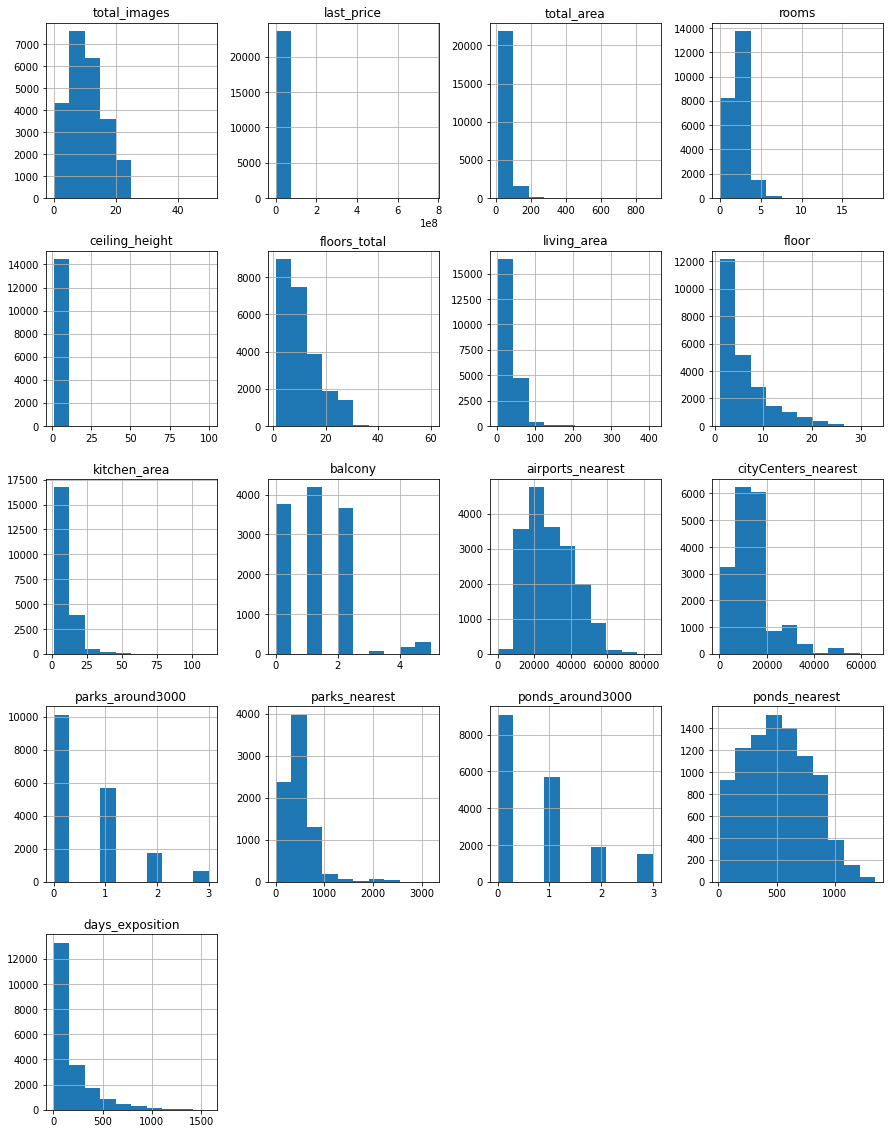

In [7]:
df.hist(figsize=(15, 20));

Подвывод: 
    - выявленно большое количество отсутствующих значений;
    - типы данных некорректны;
    - названия столбцов не соответствует нужному регистру;
    - странная группировка столбцов.

### Выполните предобработку данных

In [8]:
# разберемся сначала с названиями столбцов, посмотрим их
df.columns.tolist()

['total_images',
 'last_price',
 'total_area',
 'first_day_exposition',
 'rooms',
 'ceiling_height',
 'floors_total',
 'living_area',
 'floor',
 'is_apartment',
 'studio',
 'open_plan',
 'kitchen_area',
 'balcony',
 'locality_name',
 'airports_nearest',
 'cityCenters_nearest',
 'parks_around3000',
 'parks_nearest',
 'ponds_around3000',
 'ponds_nearest',
 'days_exposition']

In [9]:
# переименуем столбцы (приведем к нужному нам регистру)
df = df.rename(
    columns={
        'cityCenters_nearest': 'city_centers_nearest',
        'parks_around3000': 'park_around_3km',
        'ponds_around3000': 'pond_around_3km',
    }
)

In [10]:
# посмотрим переименовались ли стобцы
df.columns.tolist()

['total_images',
 'last_price',
 'total_area',
 'first_day_exposition',
 'rooms',
 'ceiling_height',
 'floors_total',
 'living_area',
 'floor',
 'is_apartment',
 'studio',
 'open_plan',
 'kitchen_area',
 'balcony',
 'locality_name',
 'airports_nearest',
 'city_centers_nearest',
 'park_around_3km',
 'parks_nearest',
 'pond_around_3km',
 'ponds_nearest',
 'days_exposition']

In [11]:
# посмотрим сколько пропусков осталось
df.isnull().sum().sort_values()

total_images                0
open_plan                   0
floor                       0
rooms                       0
studio                      0
total_area                  0
last_price                  0
first_day_exposition        0
locality_name              49
floors_total               86
living_area              1903
kitchen_area             2278
days_exposition          3181
pond_around_3km          5518
park_around_3km          5518
city_centers_nearest     5519
airports_nearest         5542
ceiling_height           9195
balcony                 11519
ponds_nearest           14589
parks_nearest           15620
is_apartment            20924
dtype: int64

In [12]:
# поменяем порядок столбцов, чтобы не резало глаз
# место, что продается, стоимость, время, а потом уже доп. информация (парки, водоемы, аэропорты)
df = df[[
    'locality_name',
    'total_area',
    'living_area',
    'kitchen_area',
    'ceiling_height',
    'rooms',
    'balcony',
    'floor',
    'floors_total',
    'is_apartment',
    'studio',
    'open_plan',
    'total_images',
    'last_price',
    'first_day_exposition',
    'days_exposition',
    'city_centers_nearest',
    'airports_nearest',
    'park_around_3km',
    'parks_nearest',
    'pond_around_3km',
    'ponds_nearest'
]]

In [13]:
# посмотрим
df.head(10)

,locality_name,total_area,living_area,kitchen_area,ceiling_height,rooms,balcony,floor,floors_total,is_apartment,studio,open_plan,total_images,last_price,first_day_exposition,days_exposition,city_centers_nearest,airports_nearest,park_around_3km,parks_nearest,pond_around_3km,ponds_nearest
0,Санкт-Петербург,108.00,51.00,25.00,2.70,3,NaN,8,16.0,NaN,False,False,20,13000000.0,2019-03-07T00:00:00,NaN,16028.0,18863.0,1.0,482.0,2.0,755.0
1,посёлок Шушары,40.40,18.60,11.00,NaN,1,2.0,1,11.0,NaN,False,False,7,3350000.0,2018-12-04T00:00:00,81.0,18603.0,12817.0,0.0,NaN,0.0,NaN
2,Санкт-Петербург,56.00,34.30,8.30,NaN,2,0.0,4,5.0,NaN,False,False,10,5196000.0,2015-08-20T00:00:00,558.0,13933.0,21741.0,1.0,90.0,2.0,574.0
3,Санкт-Петербург,159.00,NaN,NaN,NaN,3,0.0,9,14.0,NaN,False,False,0,64900000.0,2015-07-24T00:00:00,424.0,6800.0,28098.0,2.0,84.0,3.0,234.0
4,Санкт-Петербург,100.00,32.00,41.00,3.03,2,NaN,13,14.0,NaN,False,False,2,10000000.0,2018-06-19T00:00:00,121.0,8098.0,31856.0,2.0,112.0,1.0,48.0
5,городской посёлок Янино-1,30.40,14.40,9.10,NaN,1,NaN,5,12.0,NaN,False,False,10,2890000.0,2018-09-10T00:00:00,55.0,NaN,NaN,NaN,NaN,NaN,NaN
6,посёлок Парголово,37.30,10.60,14.40,NaN,1,1.0,6,26.0,NaN,False,False,6,3700000.0,2017-11-02T00:00:00,155.0,19143.0,52996.0,0.0,NaN,0.0,NaN
7,Санкт-Петербург,71.60,NaN,18.90,NaN,2,2.0,22,24.0,NaN,False,False,5,7915000.0,2019-04-18T00:00:00,NaN,11634.0,23982.0,0.0,NaN,0.0,NaN
8,посёлок Мурино,33.16,15.43,8.81,NaN,1,NaN,26,27.0,NaN,False,False,20,2900000.0,2018-05-23T00:00:00,189.0,NaN,NaN,NaN,NaN,NaN,NaN
9,Санкт-Петербург,61.00,43.60,6.50,2.50,3,2.0,7,9.0,NaN,False,False,18,5400000.0,2017-02-26T00:00:00,289.0,15008.0,50898.0,0.0,NaN,0.0,NaN


In [14]:
# посмотрим столбец с названием города
len(df['locality_name'].unique())
# слишком много городов

365

In [15]:
# приведем все названия к нижнему регистру
df['locality_name'] = df['locality_name'].str.lower()

In [16]:
# посмотри
df['locality_name'].unique().tolist()

['санкт-петербург',
 'посёлок шушары',
 'городской посёлок янино-1',
 'посёлок парголово',
 'посёлок мурино',
 'ломоносов',
 'сертолово',
 'петергоф',
 'пушкин',
 'деревня кудрово',
 'коммунар',
 'колпино',
 'поселок городского типа красный бор',
 'гатчина',
 'поселок мурино',
 'деревня фёдоровское',
 'выборг',
 'кронштадт',
 'кировск',
 'деревня новое девяткино',
 'посёлок металлострой',
 'посёлок городского типа лебяжье',
 'посёлок городского типа сиверский',
 'поселок молодцово',
 'поселок городского типа кузьмоловский',
 'садовое товарищество новая ропша',
 'павловск',
 'деревня пикколово',
 'всеволожск',
 'волхов',
 'кингисепп',
 'приозерск',
 'сестрорецк',
 'деревня куттузи',
 'посёлок аннино',
 'поселок городского типа ефимовский',
 'посёлок плодовое',
 'деревня заклинье',
 'поселок торковичи',
 'поселок первомайское',
 'красное село',
 'посёлок понтонный',
 'сясьстрой',
 'деревня старая',
 'деревня лесколово',
 'посёлок новый свет',
 'сланцы',
 'село путилово',
 'ивангород',
 '

In [17]:
# есть проблема с буквой "ё", надо ее решить
df['locality_name'] = df['locality_name'].str.replace('ё', 'е')

In [18]:
# проверка
len(df['locality_name'].unique())
# немного городов убрали, с остальной информацией позже, так как достоверность информации (дубли или нет) не уточнить

331

In [19]:
df['locality_name'].value_counts()

санкт-петербург               15721
поселок мурино                  556
поселок шушары                  440
всеволожск                      398
пушкин                          369
                              ...  
деревня вахнова кара              1
поселок кирпичное                 1
деревня большая пустомержа        1
деревня большой сабск             1
деревня курковицы                 1
Name: locality_name, Length: 330, dtype: int64

In [20]:
df[df.locality_name.isnull()].head()

,locality_name,total_area,living_area,kitchen_area,ceiling_height,rooms,balcony,floor,floors_total,is_apartment,studio,open_plan,total_images,last_price,first_day_exposition,days_exposition,city_centers_nearest,airports_nearest,park_around_3km,parks_nearest,pond_around_3km,ponds_nearest
1097,NaN,81.7,50.8,8.8,3.55,3,0.0,2,5.0,NaN,False,False,3,8600000.0,2016-04-15T00:00:00,147.0,4258.0,23478.0,0.0,NaN,0.0,NaN
2033,NaN,80.0,42.6,18.6,NaN,3,0.0,2,4.0,NaN,False,False,6,5398000.0,2017-05-30T00:00:00,34.0,NaN,NaN,NaN,NaN,NaN,NaN
2603,NaN,42.7,15.6,10.7,NaN,1,0.0,3,24.0,NaN,False,False,20,3351765.0,2015-09-20T00:00:00,276.0,17369.0,22041.0,0.0,NaN,1.0,374.0
2632,NaN,62.4,33.1,8.2,NaN,2,0.0,21,24.0,NaN,False,False,2,5130593.0,2015-10-11T00:00:00,256.0,17369.0,22041.0,0.0,NaN,1.0,374.0
3574,NaN,46.5,30.8,6.5,NaN,2,0.0,5,5.0,NaN,False,False,10,4200000.0,2016-05-28T00:00:00,45.0,8127.0,27419.0,0.0,NaN,1.0,603.0


In [21]:
# проверим незаполненные значения в данном столбце
df['locality_name'].isna().sum()

49

In [22]:
# удалим эти пропуски
df = df.dropna(subset=['locality_name'])

In [23]:
# проверим
df['locality_name'].isna().sum()

0

In [24]:
# посмотрии информацию
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 23650 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   locality_name         23650 non-null  object 
 1   total_area            23650 non-null  float64
 2   living_area           21752 non-null  float64
 3   kitchen_area          21381 non-null  float64
 4   ceiling_height        14490 non-null  float64
 5   rooms                 23650 non-null  int64  
 6   balcony               12137 non-null  float64
 7   floor                 23650 non-null  int64  
 8   floors_total          23565 non-null  float64
 9   is_apartment          2760 non-null   object 
 10  studio                23650 non-null  bool   
 11  open_plan             23650 non-null  bool   
 12  total_images          23650 non-null  int64  
 13  last_price            23650 non-null  float64
 14  first_day_exposition  23650 non-null  object 
 15  days_exposition    

In [25]:
# посмотрим такие жилые помещения как апартаменты
df['is_apartment'].unique()

array([nan, False, True], dtype=object)

In [26]:
# заменим nan
df['is_apartment'] = df['is_apartment'].fillna(0)

In [27]:
# переведем тип object к int
df['is_apartment'] = df['is_apartment'].astype('int')

In [28]:
# посмотрим
df.head()

,locality_name,total_area,living_area,kitchen_area,ceiling_height,rooms,balcony,floor,floors_total,is_apartment,studio,open_plan,total_images,last_price,first_day_exposition,days_exposition,city_centers_nearest,airports_nearest,park_around_3km,parks_nearest,pond_around_3km,ponds_nearest
0,санкт-петербург,108.0,51.0,25.0,2.70,3,NaN,8,16.0,0,False,False,20,13000000.0,2019-03-07T00:00:00,NaN,16028.0,18863.0,1.0,482.0,2.0,755.0
1,поселок шушары,40.4,18.6,11.0,NaN,1,2.0,1,11.0,0,False,False,7,3350000.0,2018-12-04T00:00:00,81.0,18603.0,12817.0,0.0,NaN,0.0,NaN
2,санкт-петербург,56.0,34.3,8.3,NaN,2,0.0,4,5.0,0,False,False,10,5196000.0,2015-08-20T00:00:00,558.0,13933.0,21741.0,1.0,90.0,2.0,574.0
3,санкт-петербург,159.0,NaN,NaN,NaN,3,0.0,9,14.0,0,False,False,0,64900000.0,2015-07-24T00:00:00,424.0,6800.0,28098.0,2.0,84.0,3.0,234.0
4,санкт-петербург,100.0,32.0,41.0,3.03,2,NaN,13,14.0,0,False,False,2,10000000.0,2018-06-19T00:00:00,121.0,8098.0,31856.0,2.0,112.0,1.0,48.0


In [29]:
# посмотрим такие жилые помещения как студия
df['studio'].unique()

array([False,  True])

In [30]:
# посмотрим по убыванию прибывание уникальных значений
df['studio'].value_counts()

False    23501
True       149
Name: studio, dtype: int64

In [31]:
df['studio'] = df['studio'].astype('int')

In [32]:
df.head()

,locality_name,total_area,living_area,kitchen_area,ceiling_height,rooms,balcony,floor,floors_total,is_apartment,studio,open_plan,total_images,last_price,first_day_exposition,days_exposition,city_centers_nearest,airports_nearest,park_around_3km,parks_nearest,pond_around_3km,ponds_nearest
0,санкт-петербург,108.0,51.0,25.0,2.70,3,NaN,8,16.0,0,0,False,20,13000000.0,2019-03-07T00:00:00,NaN,16028.0,18863.0,1.0,482.0,2.0,755.0
1,поселок шушары,40.4,18.6,11.0,NaN,1,2.0,1,11.0,0,0,False,7,3350000.0,2018-12-04T00:00:00,81.0,18603.0,12817.0,0.0,NaN,0.0,NaN
2,санкт-петербург,56.0,34.3,8.3,NaN,2,0.0,4,5.0,0,0,False,10,5196000.0,2015-08-20T00:00:00,558.0,13933.0,21741.0,1.0,90.0,2.0,574.0
3,санкт-петербург,159.0,NaN,NaN,NaN,3,0.0,9,14.0,0,0,False,0,64900000.0,2015-07-24T00:00:00,424.0,6800.0,28098.0,2.0,84.0,3.0,234.0
4,санкт-петербург,100.0,32.0,41.0,3.03,2,NaN,13,14.0,0,0,False,2,10000000.0,2018-06-19T00:00:00,121.0,8098.0,31856.0,2.0,112.0,1.0,48.0


In [33]:
# делаем всё то же самое
# посмотрим жилые помещения открытого плана
df['open_plan'].unique()

array([False,  True])

In [34]:
df['open_plan'].value_counts()

False    23583
True        67
Name: open_plan, dtype: int64

In [35]:
df['open_plan'] = df['open_plan'].astype('int')

In [36]:
df.head()

,locality_name,total_area,living_area,kitchen_area,ceiling_height,rooms,balcony,floor,floors_total,is_apartment,studio,open_plan,total_images,last_price,first_day_exposition,days_exposition,city_centers_nearest,airports_nearest,park_around_3km,parks_nearest,pond_around_3km,ponds_nearest
0,санкт-петербург,108.0,51.0,25.0,2.70,3,NaN,8,16.0,0,0,0,20,13000000.0,2019-03-07T00:00:00,NaN,16028.0,18863.0,1.0,482.0,2.0,755.0
1,поселок шушары,40.4,18.6,11.0,NaN,1,2.0,1,11.0,0,0,0,7,3350000.0,2018-12-04T00:00:00,81.0,18603.0,12817.0,0.0,NaN,0.0,NaN
2,санкт-петербург,56.0,34.3,8.3,NaN,2,0.0,4,5.0,0,0,0,10,5196000.0,2015-08-20T00:00:00,558.0,13933.0,21741.0,1.0,90.0,2.0,574.0
3,санкт-петербург,159.0,NaN,NaN,NaN,3,0.0,9,14.0,0,0,0,0,64900000.0,2015-07-24T00:00:00,424.0,6800.0,28098.0,2.0,84.0,3.0,234.0
4,санкт-петербург,100.0,32.0,41.0,3.03,2,NaN,13,14.0,0,0,0,2,10000000.0,2018-06-19T00:00:00,121.0,8098.0,31856.0,2.0,112.0,1.0,48.0


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 23650 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   locality_name         23650 non-null  object 
 1   total_area            23650 non-null  float64
 2   living_area           21752 non-null  float64
 3   kitchen_area          21381 non-null  float64
 4   ceiling_height        14490 non-null  float64
 5   rooms                 23650 non-null  int64  
 6   balcony               12137 non-null  float64
 7   floor                 23650 non-null  int64  
 8   floors_total          23565 non-null  float64
 9   is_apartment          23650 non-null  int64  
 10  studio                23650 non-null  int64  
 11  open_plan             23650 non-null  int64  
 12  total_images          23650 non-null  int64  
 13  last_price            23650 non-null  float64
 14  first_day_exposition  23650 non-null  object 
 15  days_exposition    

In [38]:
# балконы
df['balcony'].unique()
# nan мог просто появиться, забыли вписать (например)

array([nan,  2.,  0.,  1.,  5.,  4.,  3.])

In [39]:
# все норм
df['balcony'].value_counts().sort_values()

3.0      81
4.0     182
5.0     304
2.0    3658
0.0    3725
1.0    4187
Name: balcony, dtype: int64

In [40]:
# переделаем формат дня публикации объявлений
df['first_day_exposition'] = pd.to_datetime(df['first_day_exposition'], format="%Y-%m-%dT%H:%M:%S")

In [41]:
df.head()

,locality_name,total_area,living_area,kitchen_area,ceiling_height,rooms,balcony,floor,floors_total,is_apartment,studio,open_plan,total_images,last_price,first_day_exposition,days_exposition,city_centers_nearest,airports_nearest,park_around_3km,parks_nearest,pond_around_3km,ponds_nearest
0,санкт-петербург,108.0,51.0,25.0,2.70,3,NaN,8,16.0,0,0,0,20,13000000.0,2019-03-07,NaN,16028.0,18863.0,1.0,482.0,2.0,755.0
1,поселок шушары,40.4,18.6,11.0,NaN,1,2.0,1,11.0,0,0,0,7,3350000.0,2018-12-04,81.0,18603.0,12817.0,0.0,NaN,0.0,NaN
2,санкт-петербург,56.0,34.3,8.3,NaN,2,0.0,4,5.0,0,0,0,10,5196000.0,2015-08-20,558.0,13933.0,21741.0,1.0,90.0,2.0,574.0
3,санкт-петербург,159.0,NaN,NaN,NaN,3,0.0,9,14.0,0,0,0,0,64900000.0,2015-07-24,424.0,6800.0,28098.0,2.0,84.0,3.0,234.0
4,санкт-петербург,100.0,32.0,41.0,3.03,2,NaN,13,14.0,0,0,0,2,10000000.0,2018-06-19,121.0,8098.0,31856.0,2.0,112.0,1.0,48.0


подвывод: таблицу привели в удобной восприимчивости, да пропуски остались, но точно гарантировать их ненужность нельзя, по-этому оставляем как есть

### Добавьте в таблицу новые столбцы

In [42]:
# теперь посмотрим, какие столбцы мы мождем добавить для дальнейшего анализа и удобства
# начнем со стоимость 1-го квадратного метра
df['price_m2'] = df['last_price']/df['total_area']
df['price_m2'] = df['price_m2'].round(decimals=2)

In [43]:
df.head()

,locality_name,total_area,living_area,kitchen_area,ceiling_height,rooms,balcony,floor,floors_total,is_apartment,studio,open_plan,total_images,last_price,first_day_exposition,days_exposition,city_centers_nearest,airports_nearest,park_around_3km,parks_nearest,pond_around_3km,ponds_nearest,price_m2
0,санкт-петербург,108.0,51.0,25.0,2.70,3,NaN,8,16.0,0,0,0,20,13000000.0,2019-03-07,NaN,16028.0,18863.0,1.0,482.0,2.0,755.0,120370.37
1,поселок шушары,40.4,18.6,11.0,NaN,1,2.0,1,11.0,0,0,0,7,3350000.0,2018-12-04,81.0,18603.0,12817.0,0.0,NaN,0.0,NaN,82920.79
2,санкт-петербург,56.0,34.3,8.3,NaN,2,0.0,4,5.0,0,0,0,10,5196000.0,2015-08-20,558.0,13933.0,21741.0,1.0,90.0,2.0,574.0,92785.71
3,санкт-петербург,159.0,NaN,NaN,NaN,3,0.0,9,14.0,0,0,0,0,64900000.0,2015-07-24,424.0,6800.0,28098.0,2.0,84.0,3.0,234.0,408176.10
4,санкт-петербург,100.0,32.0,41.0,3.03,2,NaN,13,14.0,0,0,0,2,10000000.0,2018-06-19,121.0,8098.0,31856.0,2.0,112.0,1.0,48.0,100000.00


In [44]:
# добавим столбцы даты размещения (день недели, месяц, год)
df['day_of_week_exposition'] = df['first_day_exposition'].dt.day_name()
df['month_exposition'] = df['first_day_exposition'].dt.month_name()
df['year_exposition'] = df['first_day_exposition'].dt.year

In [45]:
df.head()

,locality_name,total_area,living_area,kitchen_area,ceiling_height,rooms,balcony,floor,floors_total,is_apartment,studio,open_plan,total_images,last_price,first_day_exposition,days_exposition,city_centers_nearest,airports_nearest,park_around_3km,parks_nearest,pond_around_3km,ponds_nearest,price_m2,day_of_week_exposition,month_exposition,year_exposition
0,санкт-петербург,108.0,51.0,25.0,2.70,3,NaN,8,16.0,0,0,0,20,13000000.0,2019-03-07,NaN,16028.0,18863.0,1.0,482.0,2.0,755.0,120370.37,Thursday,March,2019
1,поселок шушары,40.4,18.6,11.0,NaN,1,2.0,1,11.0,0,0,0,7,3350000.0,2018-12-04,81.0,18603.0,12817.0,0.0,NaN,0.0,NaN,82920.79,Tuesday,December,2018
2,санкт-петербург,56.0,34.3,8.3,NaN,2,0.0,4,5.0,0,0,0,10,5196000.0,2015-08-20,558.0,13933.0,21741.0,1.0,90.0,2.0,574.0,92785.71,Thursday,August,2015
3,санкт-петербург,159.0,NaN,NaN,NaN,3,0.0,9,14.0,0,0,0,0,64900000.0,2015-07-24,424.0,6800.0,28098.0,2.0,84.0,3.0,234.0,408176.10,Friday,July,2015
4,санкт-петербург,100.0,32.0,41.0,3.03,2,NaN,13,14.0,0,0,0,2,10000000.0,2018-06-19,121.0,8098.0,31856.0,2.0,112.0,1.0,48.0,100000.00,Tuesday,June,2018


In [46]:
# с помощью функции разберемся с этажами (первый, последний или другой)
def floor_status(row):
    if row['floor'] == 1:
        return 'первый'
    elif row['floor'] == row['floors_total']:
        return 'последний'
    else:
        return 'другой'

In [47]:
df['floor_status'] = df.apply(floor_status, axis=1)

In [48]:
df.head()

,locality_name,total_area,living_area,kitchen_area,ceiling_height,rooms,balcony,floor,floors_total,is_apartment,studio,open_plan,total_images,last_price,first_day_exposition,days_exposition,city_centers_nearest,airports_nearest,park_around_3km,parks_nearest,pond_around_3km,ponds_nearest,price_m2,day_of_week_exposition,month_exposition,year_exposition,floor_status
0,санкт-петербург,108.0,51.0,25.0,2.70,3,NaN,8,16.0,0,0,0,20,13000000.0,2019-03-07,NaN,16028.0,18863.0,1.0,482.0,2.0,755.0,120370.37,Thursday,March,2019,другой
1,поселок шушары,40.4,18.6,11.0,NaN,1,2.0,1,11.0,0,0,0,7,3350000.0,2018-12-04,81.0,18603.0,12817.0,0.0,NaN,0.0,NaN,82920.79,Tuesday,December,2018,первый
2,санкт-петербург,56.0,34.3,8.3,NaN,2,0.0,4,5.0,0,0,0,10,5196000.0,2015-08-20,558.0,13933.0,21741.0,1.0,90.0,2.0,574.0,92785.71,Thursday,August,2015,другой
3,санкт-петербург,159.0,NaN,NaN,NaN,3,0.0,9,14.0,0,0,0,0,64900000.0,2015-07-24,424.0,6800.0,28098.0,2.0,84.0,3.0,234.0,408176.10,Friday,July,2015,другой
4,санкт-петербург,100.0,32.0,41.0,3.03,2,NaN,13,14.0,0,0,0,2,10000000.0,2018-06-19,121.0,8098.0,31856.0,2.0,112.0,1.0,48.0,100000.00,Tuesday,June,2018,другой


In [49]:
df['city_centers_nearest_km'] = df['city_centers_nearest']/1000
df['city_centers_nearest_km'] = df['city_centers_nearest_km'].round()

In [50]:
df.head()

,locality_name,total_area,living_area,kitchen_area,ceiling_height,rooms,balcony,floor,floors_total,is_apartment,studio,open_plan,total_images,last_price,first_day_exposition,days_exposition,city_centers_nearest,airports_nearest,park_around_3km,parks_nearest,pond_around_3km,ponds_nearest,price_m2,day_of_week_exposition,month_exposition,year_exposition,floor_status,city_centers_nearest_km
0,санкт-петербург,108.0,51.0,25.0,2.70,3,NaN,8,16.0,0,0,0,20,13000000.0,2019-03-07,NaN,16028.0,18863.0,1.0,482.0,2.0,755.0,120370.37,Thursday,March,2019,другой,16.0
1,поселок шушары,40.4,18.6,11.0,NaN,1,2.0,1,11.0,0,0,0,7,3350000.0,2018-12-04,81.0,18603.0,12817.0,0.0,NaN,0.0,NaN,82920.79,Tuesday,December,2018,первый,19.0
2,санкт-петербург,56.0,34.3,8.3,NaN,2,0.0,4,5.0,0,0,0,10,5196000.0,2015-08-20,558.0,13933.0,21741.0,1.0,90.0,2.0,574.0,92785.71,Thursday,August,2015,другой,14.0
3,санкт-петербург,159.0,NaN,NaN,NaN,3,0.0,9,14.0,0,0,0,0,64900000.0,2015-07-24,424.0,6800.0,28098.0,2.0,84.0,3.0,234.0,408176.10,Friday,July,2015,другой,7.0
4,санкт-петербург,100.0,32.0,41.0,3.03,2,NaN,13,14.0,0,0,0,2,10000000.0,2018-06-19,121.0,8098.0,31856.0,2.0,112.0,1.0,48.0,100000.00,Tuesday,June,2018,другой,8.0


подвывод: столбцы добавлены

### Проведите исследовательский анализ данных

1. Проанализируем данные параметры.

In [51]:
# изучим некоторые параметры и построим отдельные гистограммы для каждого из них
# начнем с общей площади
df['total_area'].describe()
# да, общая площадб в 900 м2 напрягает, либо что-то на богатом

count    23650.000000
mean        60.329069
std         35.661808
min         12.000000
25%         40.000000
50%         52.000000
75%         69.700000
max        900.000000
Name: total_area, dtype: float64

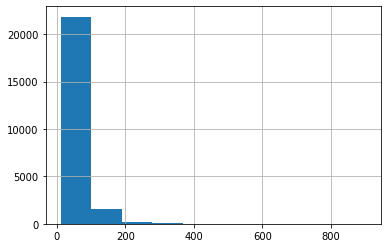

In [52]:
df['total_area'].hist();

In [53]:
# заменим пустые значения в столбце медианами
median_ceiling_total_area = df['total_area'].median()
df['total_area'].fillna(median_ceiling_total_area, inplace=True)
# удалим выбросы
Q1 = df['total_area'].quantile(0.25)
Q3 = df['total_area'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['total_area'] >= lower_bound) & (df['total_area'] <= upper_bound)]

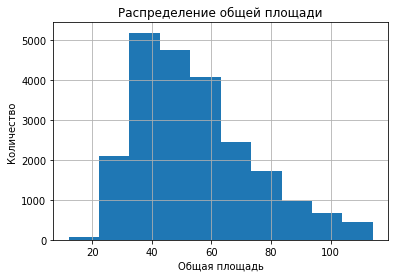

In [54]:
df['total_area'].hist()
plt.title('Распределение общей площади')
plt.xlabel('Общая площадь')
plt.ylabel('Количество')
plt.show()

Самые высокие показатели по продажам у квартир около 40 м2

In [55]:
# жилая площадь
df['living_area'].describe()

count    20637.000000
mean        31.055028
std         13.482156
min          2.000000
25%         18.300000
50%         29.780000
75%         40.000000
max        101.000000
Name: living_area, dtype: float64

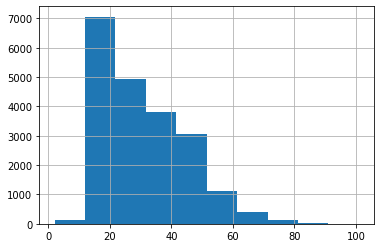

In [56]:
df['living_area'].hist();

С жилой площадью до 20 м2.

In [57]:
# площадь кухни
df['kitchen_area'].describe()

count    20250.000000
mean         9.899189
std          4.334809
min          1.300000
25%          7.000000
50%          9.000000
75%         11.297500
max         55.700000
Name: kitchen_area, dtype: float64

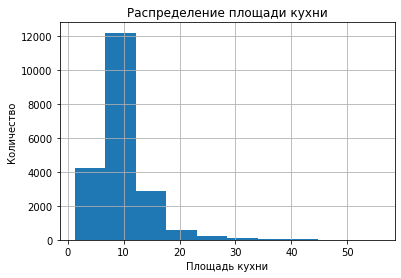

In [58]:
df['kitchen_area'].hist()
plt.title('Распределение площади кухни')
plt.xlabel('Площадь кухни')
plt.ylabel('Количество')
plt.show()

С площадь кухни в среднем до 10 м2

In [59]:
# цена объекта
df['price_m2'].describe()

count     22406.000000
mean      96035.773905
std       37984.228789
min         111.830000
25%       75793.177500
50%       94161.255000
75%      112462.127500
max      848484.850000
Name: price_m2, dtype: float64

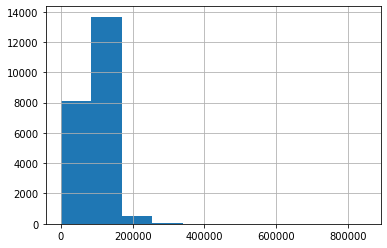

In [60]:
df['price_m2'].hist();

In [61]:
# заменим пустые значения в столбце медианами
median_ceiling_price_m2 = df['price_m2'].median()
df['price_m2'].fillna(median_ceiling_price_m2, inplace=True)
# удалим выбросы
Q1 = df['price_m2'].quantile(0.25)
Q3 = df['price_m2'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['price_m2'] >= lower_bound) & (df['price_m2'] <= upper_bound)]

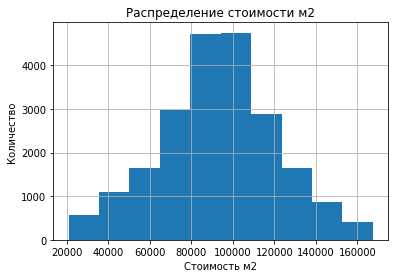

In [62]:
df['price_m2'].hist()
plt.title('Распределение стоимости м2')
plt.xlabel('Стоимость м2')
plt.ylabel('Количество')
plt.show()

В среднем покупают объекты за 80000 - 110000 за м2.

In [63]:
# комнаты
df['rooms'].describe()

count    21568.000000
mean         1.943806
std          0.902588
min          0.000000
25%          1.000000
50%          2.000000
75%          3.000000
max          7.000000
Name: rooms, dtype: float64

In [64]:
# заменим пустые значения в столбце медианами
median_ceiling_rooms = df['rooms'].median()
df['rooms'].fillna(median_ceiling_rooms, inplace=True)
# удалим выбросы
Q1 = df['rooms'].quantile(0.25)
Q3 = df['rooms'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['rooms'] >= lower_bound) & (df['rooms'] <= upper_bound)]

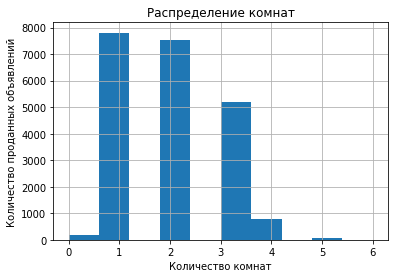

In [65]:
df['rooms'].hist()
plt.title('Распределение комнат')
plt.xlabel('Количество комнат')
plt.ylabel('Количество проданных объявлений')
plt.show()

Здесь данные выглядят правдоподобно, по-этому с выбросами работать не пришлось, ничего аномального не выявленно.
В среднем лучше продаются объявления с 1 или 2 комнатами.

In [66]:
# потолки
df['ceiling_height'].describe()
# сильно бросается в глаза потолок высотой 1 м, а также потолок высотой 32 м (но это может что-то на богатом или же это 3,2 м)

count    13135.000000
mean         2.730109
std          0.981727
min          1.000000
25%          2.500000
50%          2.600000
75%          2.750000
max         32.000000
Name: ceiling_height, dtype: float64

In [67]:
def adjust_ceiling_height(height):
    if height >= 25:
        return height / 10
    else:
        return height

df['ceiling_height'] = df['ceiling_height'].apply(adjust_ceiling_height)

In [68]:
df['ceiling_height'].describe()

count    13135.000000
mean         2.697117
std          0.407559
min          1.000000
25%          2.500000
50%          2.600000
75%          2.750000
max         24.000000
Name: ceiling_height, dtype: float64

In [69]:
# заменим пустые значения в столбце медианами
median_ceiling_height = df['ceiling_height'].median()
df['ceiling_height'].fillna(median_ceiling_height, inplace=True)
# удалим выбросы
Q1 = df['ceiling_height'].quantile(0.25)
Q3 = df['ceiling_height'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['ceiling_height'] >= lower_bound) & (df['ceiling_height'] <= upper_bound)]

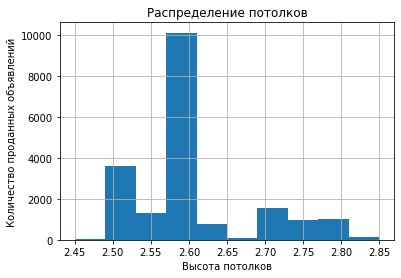

In [70]:
df['ceiling_height'].hist()
plt.title('Распределение потолков')
plt.xlabel('Высота потолков')
plt.ylabel('Количество проданных объявлений')
plt.show()

Чаще продаются жилые помещения с высотой потолков 2,6 м.

In [71]:
# тип этажа
df['floor_status'].describe()

count      19587
unique         3
top       другой
freq       14656
Name: floor_status, dtype: object

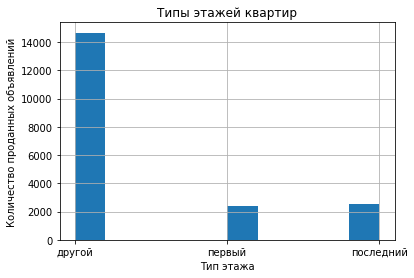

In [72]:
df['floor_status'].hist()
plt.title('Типы этажей квартир')
plt.xlabel('Тип этажа')
plt.ylabel('Количество проданных объявлений')
plt.show()

Явно видим, что люди предпочитают квартиры не на первом или последнем этажах.

In [73]:
# общее количество этаже
df['floors_total'].describe()
# 60 этажей ... может высотка?

count    19512.000000
mean        11.294537
std          6.677386
min          1.000000
25%          5.000000
50%          9.000000
75%         16.000000
max         52.000000
Name: floors_total, dtype: float64

In [74]:
# заменим пустые значения в столбце медианами
median_ceiling_floors_total = df['floors_total'].median()
df['floors_total'].fillna(median_ceiling_floors_total, inplace=True)
# удалим выбросы
Q1 = df['floors_total'].quantile(0.25)
Q3 = df['floors_total'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['floors_total'] >= lower_bound) & (df['floors_total'] <= upper_bound)]

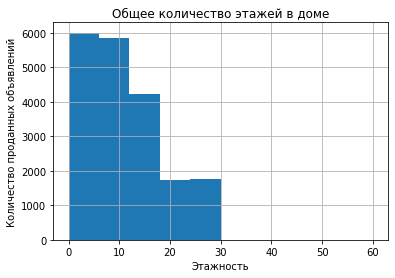

In [75]:
df['floors_total'].hist(range=(0, 60))
plt.title('Общее количество этажей в доме')
plt.xlabel('Этажность')
plt.ylabel('Количество проданных объявлений')
plt.show()

В среднем люди предпочитают дома до 10 этажей.

In [76]:
# расстояния до центра
df['city_centers_nearest_km'].describe()

count    14499.000000
mean        15.574798
std          8.224299
min          0.000000
25%         11.000000
50%         14.000000
75%         17.000000
max         66.000000
Name: city_centers_nearest_km, dtype: float64

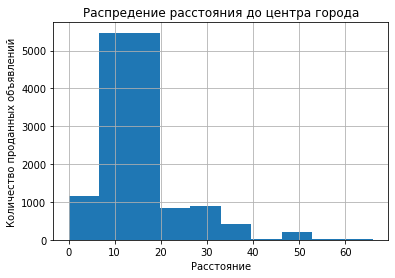

In [77]:
df['city_centers_nearest_km'].hist()
plt.title('Распредение расстояния до центра города')
plt.xlabel('Расстояние')
plt.ylabel('Количество проданных объявлений')
plt.show()

Видим, что чаще выбираются объявления до 20 км от центра.

In [78]:
# ближайшие парки
df['parks_nearest'].describe()

count    5643.000000
mean      504.569024
std       340.931661
min         1.000000
25%       303.500000
50%       470.000000
75%       627.000000
max      3190.000000
Name: parks_nearest, dtype: float64

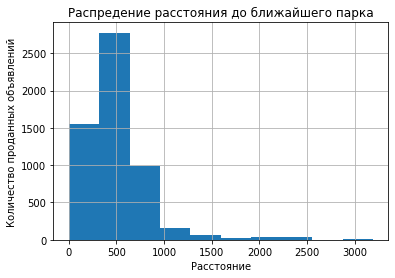

In [79]:
df['parks_nearest'].hist()
plt.title('Распредение расстояния до ближайшего парка')
plt.xlabel('Расстояние')
plt.ylabel('Количество проданных объявлений')
plt.show()

Видим, что чаще расходятся объявления в ближайшими парками (примерно до 800 м).

2. Теперь проанализируем как быстро продавались квартиры.

In [80]:
df['days_exposition'].describe()

count    17273.000000
mean       169.150698
std        207.317990
min          1.000000
25%         43.000000
50%         90.000000
75%        213.000000
max       1580.000000
Name: days_exposition, dtype: float64

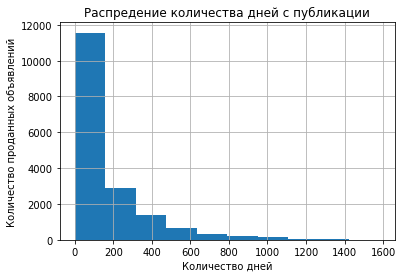

In [81]:
df['days_exposition'].hist()
plt.title('Распредение количества дней с публикации')
plt.xlabel('Количество дней')
plt.ylabel('Количество проданных объявлений')
plt.show()
# надо смотреть детальнее

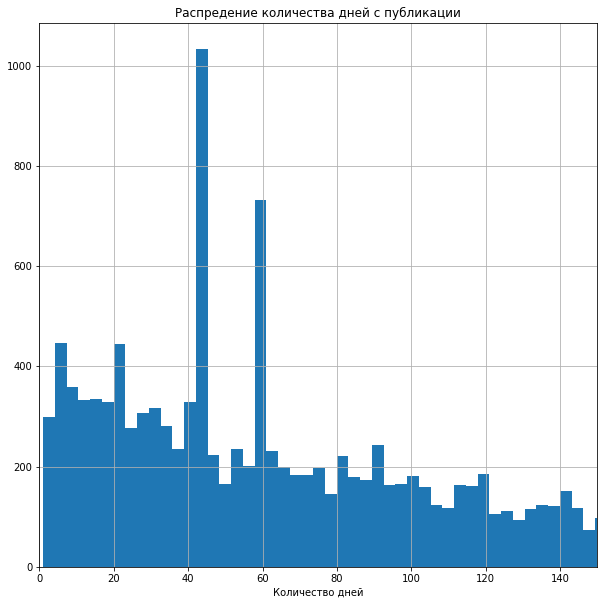

In [82]:
plt.figure(figsize=(10, 10))
df.days_exposition.hist(bins=500)
plt.title('Распредение количества дней с публикации')
plt.xlabel('Количество дней')
plt.xlim(0, 150)
plt.show()

In [83]:
df.head()

,locality_name,total_area,living_area,kitchen_area,ceiling_height,rooms,balcony,floor,floors_total,is_apartment,studio,open_plan,total_images,last_price,first_day_exposition,days_exposition,city_centers_nearest,airports_nearest,park_around_3km,parks_nearest,pond_around_3km,ponds_nearest,price_m2,day_of_week_exposition,month_exposition,year_exposition,floor_status,city_centers_nearest_km
0,санкт-петербург,108.0,51.0,25.0,2.7,3,NaN,8,16.0,0,0,0,20,13000000.0,2019-03-07,NaN,16028.0,18863.0,1.0,482.0,2.0,755.0,120370.37,Thursday,March,2019,другой,16.0
1,поселок шушары,40.4,18.6,11.0,2.6,1,2.0,1,11.0,0,0,0,7,3350000.0,2018-12-04,81.0,18603.0,12817.0,0.0,NaN,0.0,NaN,82920.79,Tuesday,December,2018,первый,19.0
2,санкт-петербург,56.0,34.3,8.3,2.6,2,0.0,4,5.0,0,0,0,10,5196000.0,2015-08-20,558.0,13933.0,21741.0,1.0,90.0,2.0,574.0,92785.71,Thursday,August,2015,другой,14.0
5,городской поселок янино-1,30.4,14.4,9.1,2.6,1,NaN,5,12.0,0,0,0,10,2890000.0,2018-09-10,55.0,NaN,NaN,NaN,NaN,NaN,NaN,95065.79,Monday,September,2018,другой,NaN
6,поселок парголово,37.3,10.6,14.4,2.6,1,1.0,6,26.0,0,0,0,6,3700000.0,2017-11-02,155.0,19143.0,52996.0,0.0,NaN,0.0,NaN,99195.71,Thursday,November,2017,другой,19.0


In [84]:
# посчитаем медиану
median_days = df.pivot_table(index='year_exposition', values='days_exposition', aggfunc='median').fillna(0).reset_index()

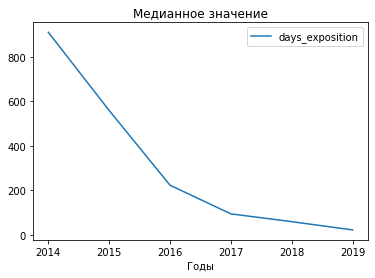

In [85]:
median_days.plot(x='year_exposition')
plt.title('Медианное значение')
plt.xlabel('Годы')
plt.show()

In [86]:
display(median_days)

,year_exposition,days_exposition
0,2014,910.0
1,2015,559.0
2,2016,223.5
3,2017,95.0
4,2018,60.0
5,2019,23.0


In [87]:
# посчитаем среднее
mean_days = df.pivot_table(index='year_exposition', values='days_exposition', aggfunc='mean').fillna(0).reset_index()

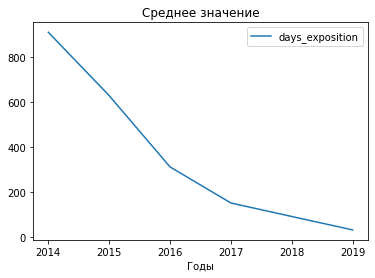

In [88]:
mean_days.plot(x='year_exposition')
plt.title('Cреднее значение')
plt.xlabel('Годы')
plt.show()

In [89]:
display(mean_days)

,year_exposition,days_exposition
0,2014,908.535211
1,2015,627.087256
2,2016,310.319320
3,2017,150.130357
4,2018,90.172025
5,2019,30.529095


Дольше всего продаются квартиры, объявления которых размещены намного раньше (2014 г.). Начиная с 2017 года все меняется, видимо возрастает спрос. С 2019 года квартира находит своего хозяина в среднем за 1 месяц.

3. Определим факторы, которые больше всего влияют на стоимость объекта.

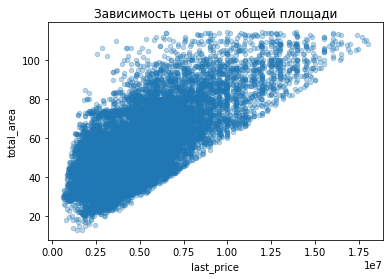

In [90]:
# посмотрим зависимость стоимости жилья от общей площади 
df.plot(x='last_price', y='total_area', kind='scatter', alpha=0.3)
plt.title('Зависимость цены от общей площади')
plt.show()

Наблюдаем положительную коррреляцию на диаграмме рассеивания между стоимостью и общей площади квартиры.

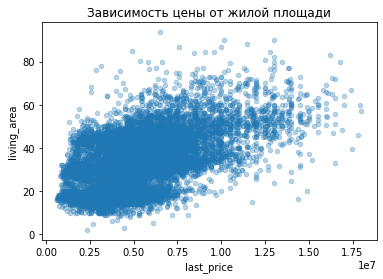

In [91]:
# посмотрим зависимость стоимости жилья от жилой площади 
df.plot(x='last_price', y='living_area', kind='scatter', alpha=0.3)
plt.title('Зависимость цены от жилой площади')
plt.show()

Наблюдаем положительную коррреляцию на диаграмме рассеивания между стоимостью и жилой площади квартиры.

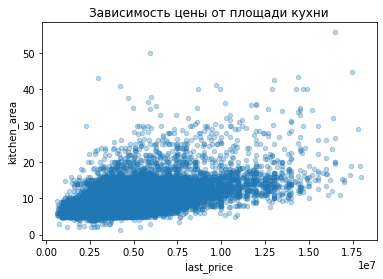

In [92]:
# посмотрим зависимость стоимости жилья от площади кухни
df.plot(x='last_price', y='kitchen_area', kind='scatter', alpha=0.3)
plt.title('Зависимость цены от площади кухни')
plt.show()

Наблюдаем положительную коррреляцию на диаграмме рассеивания между стоимостью и площади кухни квартиры.

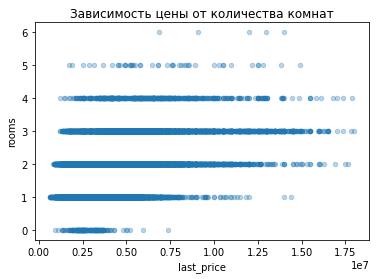

In [93]:
# посмотрим зависимость стоимости жилья от количесвта комнат
df.plot(x='last_price', y='rooms', kind='scatter', alpha=0.3)
plt.title('Зависимость цены от количества комнат')
plt.show()

Диаграмма рассеяния не так уже прозрачна (из малых значений комнат от 1 до 6), но зависимость прослеживается.

In [94]:
# посмотрим зависимость стоимости жилья от этажа, на котором расположена квартира
df.pivot_table(index='floor_status', values='last_price', aggfunc='median').reset_index()

,floor_status,last_price
0,другой,4500000.0
1,первый,3699500.0
2,последний,3900000.0


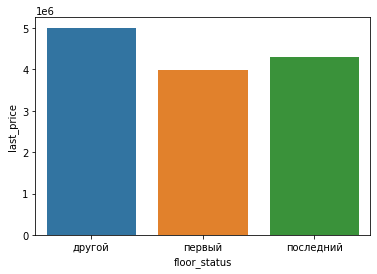

In [95]:
# Рассчитываем средние значения цены по категориям этажа
mean_price_by_floor = df.groupby('floor_status')['last_price'].mean().reset_index()

# Строим barplot
sns.barplot(x='floor_status', y='last_price', data=mean_price_by_floor);

Стоимость жилья на 1-ом этаже ниже чем на последнем, а на последнем ниже чем на каком-либо другом.

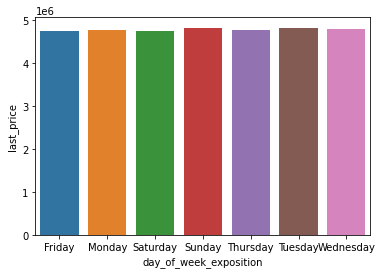

In [96]:
# теперь разберемся с датой размещения объявления
# начнем с дня недели
mean_price_by_day = df.groupby('day_of_week_exposition')['last_price'].mean().reset_index()

# Строим barplot
sns.barplot(x='day_of_week_exposition', y='last_price', data=mean_price_by_day);

Видим что квартиры хорошо распродаются во вторник.

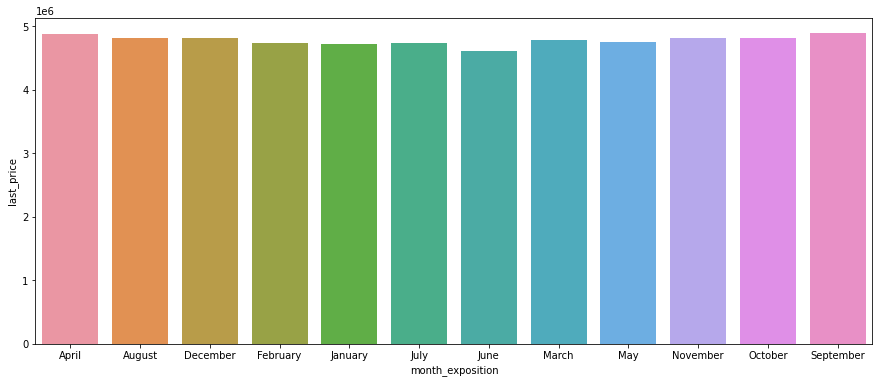

In [97]:
# месяц
mean_price_by_month = df.groupby('month_exposition')['last_price'].mean().reset_index()

# Строим barplot
plt.figure(figsize=(15, 6))
sns.barplot(x='month_exposition', y='last_price', data=mean_price_by_month);
plt.xticks(range(12))
plt.show()

Хорошие пики продаж в апреле, январе и июле.

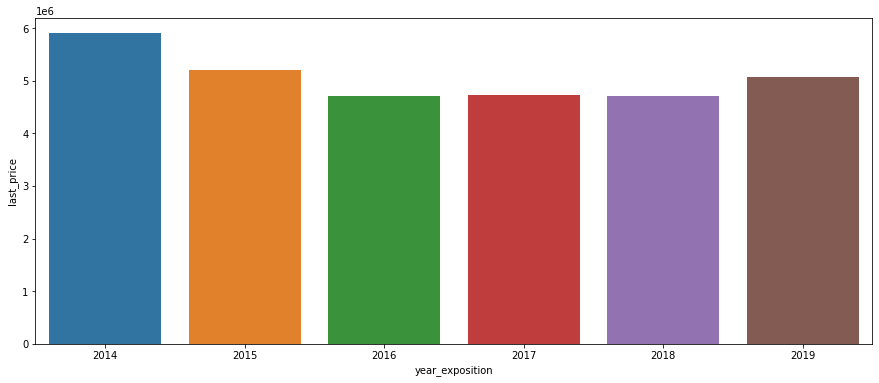

In [98]:
# и год
mean_price_by_year = df.groupby('year_exposition')['last_price'].mean().reset_index()

# Строим barplot
plt.figure(figsize=(15, 6))
sns.barplot(x='year_exposition', y='last_price', data=mean_price_by_year);

в 2014 году был пик продаж, после чего началось падения спроса, с 2019 года спрос начинает подниматься.

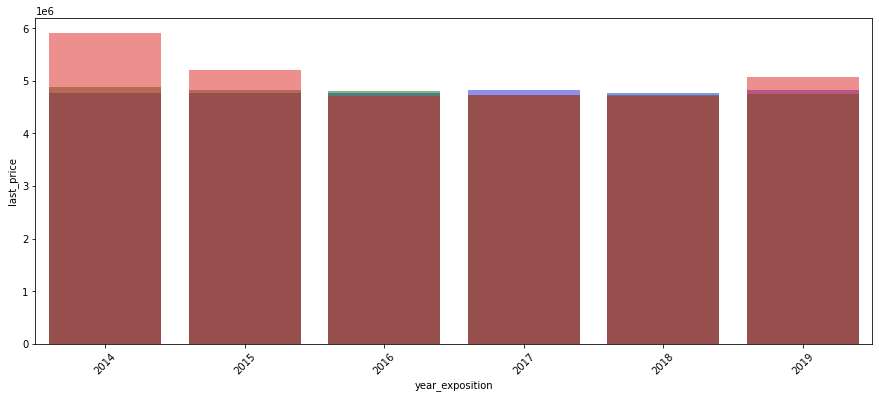

In [99]:
plt.figure(figsize=(15, 6))

# График по дням недели
sns.barplot(x='day_of_week_exposition', y='last_price', data=mean_price_by_day, color='blue', alpha=0.5)

# График по месяцам
sns.barplot(x='month_exposition', y='last_price', data=mean_price_by_month, color='green', alpha=0.5)

# График по годам
sns.barplot(x='year_exposition', y='last_price', data=mean_price_by_year, color='red', alpha=0.5)

plt.xticks(rotation=45)
plt.show()

решила построить общий график с пересечениями, что-бы что-то понять, но ничего не поняла :D

4. 

In [100]:
df.head()

,locality_name,total_area,living_area,kitchen_area,ceiling_height,rooms,balcony,floor,floors_total,is_apartment,studio,open_plan,total_images,last_price,first_day_exposition,days_exposition,city_centers_nearest,airports_nearest,park_around_3km,parks_nearest,pond_around_3km,ponds_nearest,price_m2,day_of_week_exposition,month_exposition,year_exposition,floor_status,city_centers_nearest_km
0,санкт-петербург,108.0,51.0,25.0,2.7,3,NaN,8,16.0,0,0,0,20,13000000.0,2019-03-07,NaN,16028.0,18863.0,1.0,482.0,2.0,755.0,120370.37,Thursday,March,2019,другой,16.0
1,поселок шушары,40.4,18.6,11.0,2.6,1,2.0,1,11.0,0,0,0,7,3350000.0,2018-12-04,81.0,18603.0,12817.0,0.0,NaN,0.0,NaN,82920.79,Tuesday,December,2018,первый,19.0
2,санкт-петербург,56.0,34.3,8.3,2.6,2,0.0,4,5.0,0,0,0,10,5196000.0,2015-08-20,558.0,13933.0,21741.0,1.0,90.0,2.0,574.0,92785.71,Thursday,August,2015,другой,14.0
5,городской поселок янино-1,30.4,14.4,9.1,2.6,1,NaN,5,12.0,0,0,0,10,2890000.0,2018-09-10,55.0,NaN,NaN,NaN,NaN,NaN,NaN,95065.79,Monday,September,2018,другой,NaN
6,поселок парголово,37.3,10.6,14.4,2.6,1,1.0,6,26.0,0,0,0,6,3700000.0,2017-11-02,155.0,19143.0,52996.0,0.0,NaN,0.0,NaN,99195.71,Thursday,November,2017,другой,19.0


In [101]:
df.groupby('locality_name').agg({'price_m2':'mean'}).sort_values(by='price_m2', ascending=False).head(10)

,price_m2
locality_name,
санкт-петербург,104695.696662
сестрорецк,101547.393172
пушкин,101004.793766
кудрово,100253.364620
зеленогорск,100123.735000
деревня мистолово,98549.977273
поселок левашово,96997.690000
мурино,92722.708824
деревня кудрово,92489.243986


In [102]:
# разделим, что есть Питер и пригород
def locality_name_status (row):
    if row ['locality_name'] == 'санкт-петербург':
        return 'Питер'
    else:
        return 'пригород'

In [103]:
df['locality_name_status'] = df.apply(locality_name_status, axis=1)

In [104]:
df.groupby('locality_name_status').agg({'price_m2':'mean'}).sort_values(by='price_m2', ascending=False).head(10)

,price_m2
locality_name_status,
Питер,104695.696662
пригород,69613.297265


(0.0, 200000.0)

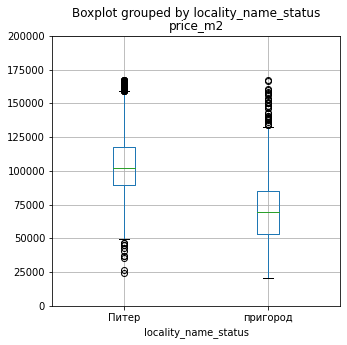

In [105]:
plot = df.boxplot('price_m2', by='locality_name_status', figsize=(5, 5))
plot.set_ylim(0,200000)

In [106]:
name_10_df = df.groupby('locality_name')\
    .agg({'locality_name_status':'count', 'price_m2':'mean'})
name_10_df = name_10_df.sort_values('locality_name_status', ascending=False).head(11)

In [107]:
name_10_df.sort_values('price_m2', ascending=False).head(11)

,locality_name_status,price_m2
locality_name,,
санкт-петербург,12263,104695.696662
пушкин,308,101004.793766
деревня кудрово,296,92489.243986
поселок парголово,326,90332.262638
поселок мурино,551,85693.188258
петергоф,186,82690.162957
поселок шушары,434,78676.193410
колпино,316,75564.529209
гатчина,283,68985.839823


<AxesSubplot:xlabel='locality_name'>

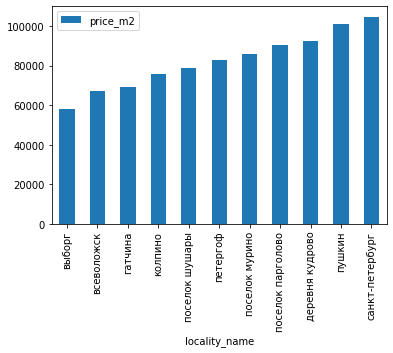

In [108]:
name_10_df.sort_values('price_m2', ascending=True)\
    .drop('locality_name_status', axis=1).plot(kind='bar')

In [109]:
top_10 = name_10_df.reset_index().locality_name.to_list()
top_10

['санкт-петербург',
 'поселок мурино',
 'поселок шушары',
 'всеволожск',
 'поселок парголово',
 'колпино',
 'пушкин',
 'деревня кудрово',
 'гатчина',
 'выборг',
 'петергоф']

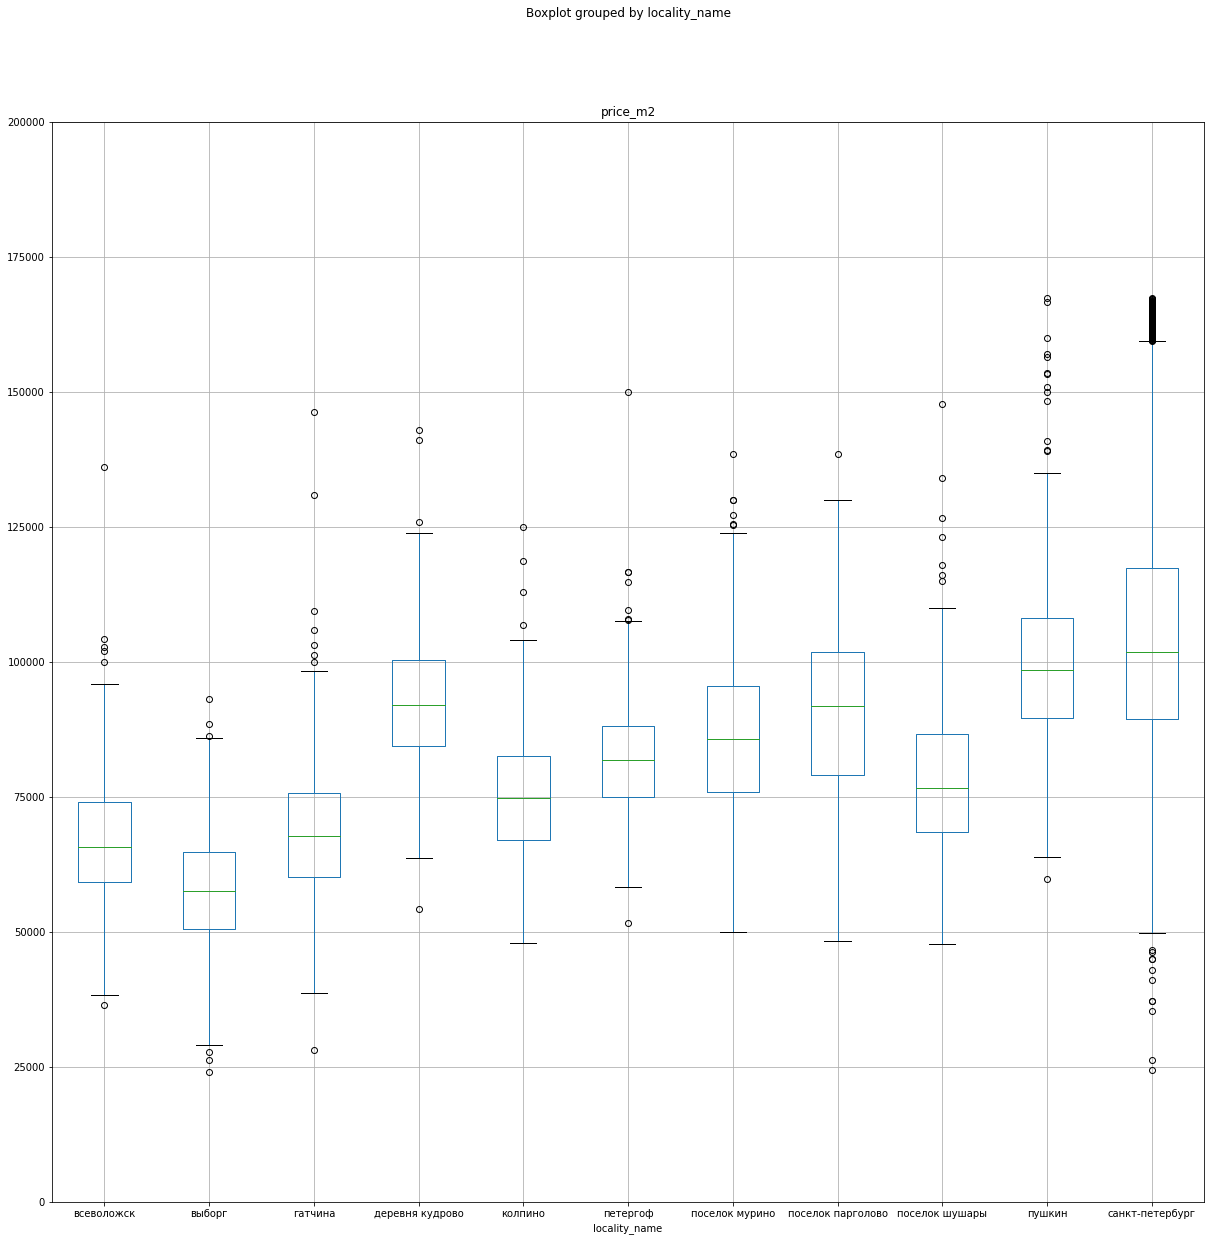

In [110]:
plot = df[df.locality_name.isin(top_10)]\
    .boxplot('price_m2', by='locality_name', figsize=(20, 20))\
    .set_ylim(0, 200000)

Очевидно. В Питере дорого, за Питером нет. Самое дешевое жилье во Всеволжске.

5. Зависимость стоимости квадрытных метров от удаленность от центра Питера.

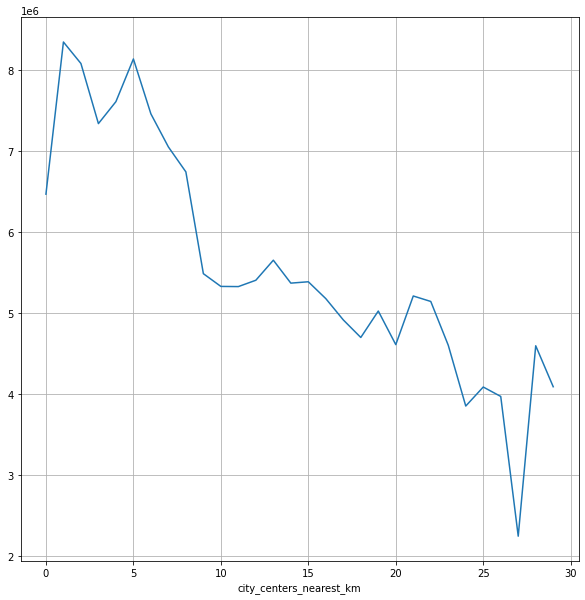

In [111]:
spb_flats = df[df['locality_name'] == 'санкт-петербург']
average_price = spb_flats.groupby('city_centers_nearest_km')['last_price'].mean()
average_price.plot(x='city_centers_nearest_km', y=average_price, grid=True, figsize=(10, 10));

Ничего неожиданного, стоимость жилья уменьшается с ростом расстояния от центра.

### Напишите общий вывод

Изучив предоставленные мне данные сервиса Яндекс Недвижимость (архив объявлений):

airports_nearest — расстояние до ближайшего аэропорта в метрах (м)
balcony — число балконов
ceiling_height — высота потолков (м)
cityCenters_nearest — расстояние до центра города (м)
days_exposition — сколько дней было размещено объявление (от публикации до снятия)
first_day_exposition — дата публикации
floor — этаж
floors_total — всего этажей в доме
is_apartment — апартаменты (булев тип)
kitchen_area — площадь кухни в квадратных метрах (м²)
last_price — цена на момент снятия с публикации
living_area — жилая площадь в квадратных метрах (м²)
locality_name — название населённого пункта
open_plan — свободная планировка (булев тип)
parks_around3000 — число парков в радиусе 3 км
parks_nearest — расстояние до ближайшего парка (м)
ponds_around3000 — число водоёмов в радиусе 3 км
ponds_nearest — расстояние до ближайшего водоёма (м)
rooms — число комнат
studio — квартира-студия (булев тип)
total_area — общая площадь квартиры в квадратных метрах (м²)
total_images — число фотографий квартиры в объявлении

было выявленно, большое количество отсутствующих значений; типы данных некорректны; названия столбцов не соответствует нужному регистру; странная группировка столбцов.
пропущенные значения в столбце населенных пунктов были удалены;
столбцы переименованы и расставлены в удобном порядке;
типы данных исправлене;
количественные значения, которые отсутствовали, не изменялись, так как могло повлиять на анализ

для удобства также были добавлены новые столбцы:
    - цена 1 квадратного метра;
    - день недели публикации;
    - месяц публикации объявления;
    - год публикации;
    - типы этажей (первый, последний или другой);
    - и расстояние от центра города в км.
    
После обработки предоставленных Вами данных, сделав анализ отвечаю на ваши вопросы:

1. Изучив интересующие вас параметры, могу сказать следующее:
общая площадь - самые высокие показатели по продажам у квартир до 40 м2;
жилая площадь - самые высокие показатели по продажам у квартир с жилой площадью до 20 м2;
площадь кухни - с площадью кухни ьв среднем до 10 м2;
цена объекта - в среднем покупают объекты стоимость 80000 - 110000 за один м2;
количество комнат - в среднем лучше продаются объявления с 1 или 2 комнатами;
высота потолков - чаще продаются жилые помещения с высотой потолков 2,6 м.;
тип этажа квартиры («первый», «последний», «другой») - люди предпочитают квартиры не на первом или последнем этажах;
общее количество этажей в доме - в среднем люди предпочитают дома до 10 этажей;
расстояние до центра города в метрах - чаще выбираются объявления до 20 км от центра и ниже;
расстояние до ближайшего парка - чаще расходятся объявления в ближайшими парками (примерно до 800 м).

2. Дольше всего продаются квартиры, объявления которых размещены намного раньше (2014 г.). Начиная с 2017 года все меняется, видимо возрастает спрос. С 2019 года квартира находит своего хозяина в среднем за 1 месяц.

3. Изучив зависимости по предоставленным параметров, могу сказать следующее:
    - цена от общей площади: зависимость есть, растет общая площадь, растет и цена;
    - жилая площадь: то же самое, растет жилая площадь, растет и цена;
    - площадь кухни: аналогично, растет площадь кухни, растет и цена;
    - количество комнат: стоимость самая большая у 3-комнатной квартиры, на 2 комнатах цена падает, на 1 комнате еще падает, однако на 4-комнаты стоимость близка к 2-хкомнатной квартире.
    - этаж, на котором расположена квартира: стоимость жилья на 1-ом этаже ниже чем на последнем, а на последнем ниже чем на каком-либо другом;
    - даты размещения: квартиры хорошо распродаются во вторник, хорошие пики продаж в апреле, январе и июле и в 2014 году был пик продаж, после чего спрос падал вплоть до 2019 г. (в 2019 г. спрос растет).
        
4. В Питере дорого, за Питером нет (начиная после 3-5 км.). Самое дешевое жилье во Всеволжске.

5. Стоимость жилья уменьшается с ростом расстояния от центра.